# Minimal Pipeline Tutorial

This notebook provides a compact, runnable walkthrough of the main modeling ideas used in the full workflow, using one WT thermodynamic model, one WT kinetic model, and one precomputed kinetic parameter set. The goal is to show how the provided model files and processed parameter subsets can be loaded and used for a representative analysis.

The first part loads the WT thermodynamic model and computes one steady-state solution. The thermodynamic model defines the feasible metabolic state space under the model constraints, including reaction bounds, metabolite constraints, and the growth objective. This steady-state solution provides the flux and concentration reference point used to initialize the kinetic model.

The second part loads the WT kinetic model and compiles the functions needed for Metabolic Control Analysis (MCA) and ODE simulation. MCA quantifies how sensitive fluxes or metabolite concentrations are to changes in kinetic parameters. In this tutorial, we compute an MCA matrix for one selected parameter set and inspect how enzyme activity (through `vmax`) parameters influence the local behavior of the model.

The final part runs one nonlinear simulation. Unlike MCA, which is a local sensitivity analysis around a steady state, the nonlinear ODE simulation follows the time-dependent response of the kinetic model after a perturbation. Here, the `vmax` value of the TMDS enzyme is directly reduced to 50% of its original value before integration. The model is then simulated for 10 model hours, and the resulting trajectories are visualized for different reactions and concentrations such as growth rate, oxygen consumption, and ATP/ADP/AMP concentrations.

All calculations use precomputed model and parameter files.

## Setup

In [2]:
import configparser
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# The examples folder is one level above scripts/utils.
if os.path.basename(os.getcwd()) == 'examples':
    repo_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
else:
    repo_dir = os.getcwd()

scripts_dir = os.path.join(repo_dir, 'scripts')
if scripts_dir not in sys.path:
    sys.path.append(scripts_dir)

from pytfa.io.json import load_json_model
from skimpy.analysis.oracle.load_pytfa_solution import load_fluxes, \
    load_concentrations, load_equilibrium_constants
from skimpy.core.parameters import load_parameter_population
from skimpy.core.solution import ODESolution
from skimpy.io.yaml import load_yaml_model
from skimpy.utils.namespace import QSSA
from skimpy.utils.tabdict import TabDict
from utils.drug_ode_simulation import solver_ode
from utils.make_flux_fun_parallel import make_flux_fun_parallel

In [87]:
PHYSIOLOGY = 'WT'
TARGET = 'TMDS'
PERTURBATION_FRACTION = 0.50
TIME = np.linspace(0, 10, 100)  # 10 model hours
REACTIONS = ['biomass', 'O2t', 'HEX1', 'PYK', 'ATPS4mi', 'GND'] # Reactions to plot after the nonlinear perturbation simulation
METABOLITES = ['atp_c', 'adp_c', 'amp_c', 'dttp_c', 'dump_c', 'pyr_c'] # Metabolites to plot after the nonlinear perturbation simulation

# Read configuration from config.ini
config = configparser.ConfigParser()
config_path = os.path.join(repo_dir, 'scripts', 'src', 'config.ini')
config.read(config_path)

# Scaling parameters from config.ini
CONCENTRATION_SCALING = float(config['scaling']['CONCENTRATION_SCALING'])
TIME_SCALING = float(config['scaling']['TIME_SCALING'])
DENSITY = float(config['scaling']['DENSITY'])
GDW_GWW_RATIO = float(config['scaling']['GDW_GWW_RATIO'])
flux_scaling_factor = 1e-3 * (GDW_GWW_RATIO * DENSITY) * CONCENTRATION_SCALING / TIME_SCALING

# Running parameters from config.ini
ncpu = int(config['global']['ncpu'])
rtol = 1e-5 # Decreasing this value will increase the time it takes to run the simulation.
atol = float(config['drug_metabolism']['atol'])
time_limit = float(config['drug_metabolism']['time_limit'])

# Paths from config.ini 
base_dir = config['paths']['base_dir']
path_to_tmodel = os.path.abspath(os.path.join(base_dir, config['paths'][f'path_to_tmodel_{PHYSIOLOGY}']))
path_to_kmodel = os.path.abspath(os.path.join(base_dir, config['paths'][f'path_to_kmodel_{PHYSIOLOGY}']))
path_to_samples = os.path.abspath(os.path.join(base_dir, config['paths'][f'path_to_samples_{PHYSIOLOGY}']))
path_to_stratified_samples = os.path.abspath(os.path.join(base_dir, config['paths'][f'path_to_stratified_samples_{PHYSIOLOGY}']))
path_to_stratified_params = os.path.abspath(os.path.join(base_dir, config['paths'][f'path_to_stratified_params_{PHYSIOLOGY}']))

def require_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError('Required file not found: {}'.format(path))

## Steps

### 1. Load the WT thermodynamic model and create one solution

In [4]:
print('Loading TFA model from:', path_to_tmodel)
require_file(path_to_tmodel)
tmodel = load_json_model(path_to_tmodel)

print('Optimizing WT TFA model...')
solution = tmodel.optimize()
print('Objective value:', solution.objective_value)
display(solution.fluxes.head())

Loading TFA model from: /kincancer/models/steady_state_models/tfa_model_WT.json


2026-07-24 13:12:11,816 - thermomodel_RelaxedModel RelaxedModel RelaxedModel redCANCER_OC_Date_08Aug2023_131854_Generated_by_redGEMv1 - INFO - # Model initialized with units kcal/mol and temperature 298.15 K


Optimizing WT TFA model...
Objective value: 0.03465735902799726


13DAMPPOX    0.001500
1MNCAMti     0.000001
2AMACHYD     0.000001
2AMADPTm     0.000001
2DR1PP       0.463705
Name: fluxes, dtype: float64

### 2. Load the WT kinetic model and compile MCA and ODE functions

In [5]:
print('Loading kinetic model from:', path_to_kmodel)
require_file(path_to_kmodel)
kmodel = load_yaml_model(path_to_kmodel)
kmodel.prepare()

# Compile MCA with enzyme vmax parameters, as in the full workflow scripts.
PARAMETER_FOR_MCA = 'vmax_forward'
parameter_list = TabDict([(k, p.symbol) for k, p in kmodel.parameters.items()
                          if p.name.startswith(PARAMETER_FOR_MCA)])

print('Compiling MCA...')
kmodel.compile_mca(sim_type=QSSA, ncpu=ncpu, parameter_list=parameter_list)

print('Compiling ODEs...')
kmodel.compile_ode(sim_type=QSSA, ncpu=ncpu)

print('Compiling flux expressions...')
calc_flux = make_flux_fun_parallel(kmodel, QSSA)

Loading kinetic model from: /kincancer/models/kinetic_models/kinetic_model_WT.yaml


2026-07-24 13:13:21,797 - Unnamed - WARNING - Non integer stoichiometries found ['biomass', 'CYOOm3i'] change to integer for linear dependencies
2026-07-24 13:14:06,426 - Unnamed - WARNING - Non integer stoichiometries found ['biomass', 'CYOOm3i'] change to integer for linear dependencies


Compiling MCA...
Compiling ODEs...
Compiling flux expressions...


### 3. Load one selected steady-state sample and one kinetic parameter set

In [ ]:
require_file(path_to_samples)
require_file(path_to_stratified_samples)
require_file(path_to_stratified_params)

samples = pd.read_csv(path_to_samples, index_col=0, header=0)
samples_picked = pd.read_csv(path_to_stratified_samples, index_col=0)
parameter_population = load_parameter_population(path_to_stratified_params)

# The stratified parameter file uses indices of the form '<steady_state_id>,<parameter_id>'.
model_ix = list(parameter_population._index.keys())[0]
steady_state_id, parameter_id = model_ix.split(',')
steady_state_id = int(steady_state_id)

tfa_sample = samples.loc[steady_state_id]
parameter_set = parameter_population[model_ix]
kmodel.parameters = parameter_set

print('Selected model index:', model_ix)
print('Selected steady-state id:', steady_state_id)
print('Selected kinetic parameter id:', parameter_id)

### 4. Load fluxes and concentrations for the selected state

In [ ]:
fluxes = load_fluxes(tfa_sample, tmodel, kmodel,
                     density=DENSITY,
                     ratio_gdw_gww=GDW_GWW_RATIO,
                     concentration_scaling=CONCENTRATION_SCALING,
                     time_scaling=TIME_SCALING)

concentrations = load_concentrations(tfa_sample, tmodel, kmodel,
                                      concentration_scaling=CONCENTRATION_SCALING)

load_equilibrium_constants(tfa_sample, tmodel, kmodel,
                           concentration_scaling=CONCENTRATION_SCALING,
                           in_place=True)

### 5. Run MCA for this one model and display the matrix

In [103]:
flux_control_coeff = kmodel.flux_control_fun(fluxes, concentrations, [parameter_set])

flux_index = pd.Index(kmodel.reactions.keys(), name='flux')
parameter_index = pd.Index(kmodel.flux_control_fun.parameter_elasticity_function.respective_variables,
                           name='parameter')

flux_mca_matrix = pd.DataFrame(flux_control_coeff._data[:, :, 0],
                               index=flux_index,
                               columns=parameter_index)

display(flux_mca_matrix)
top_enzymes = flux_mca_matrix.loc['biomass', :].abs().sort_values(ascending=False).index[:10]
display(flux_mca_matrix.loc['biomass', top_enzymes])

parameter,vmax_forward_13DAMPPOX,vmax_forward_13DAMPPte,vmax_forward_1MNCAMt,vmax_forward_1MNCAMti,vmax_forward_2AMACHYD,vmax_forward_2AMADPTm,vmax_forward_2DR1PP,vmax_forward_2HCO3_NAt,vmax_forward_2OBUTt,vmax_forward_2OXOADOXm,...,vmax_forward_r2519,vmax_forward_r2520,vmax_forward_r2521,vmax_forward_r2525,vmax_forward_r2526,vmax_forward_r2532,vmax_forward_r2534,vmax_forward_r2535,vmax_forward_r2535m,vmax_forward_r2537
flux,,,,,,,,,,,,,,,,,,,,,
13DAMPPOX,0.536381,-1.514922e-03,-1.422323e-06,-1.273306e-06,-2.497867e-07,-7.802913e-10,-0.000570,-2.179944e-04,-0.014117,-4.448712e-05,...,-2.738139e-10,3.574945e-07,1.075644e-04,-0.000029,0.000022,0.000024,0.000036,1.078646e-08,3.316624e-06,-2.389248e-06
13DAMPPte,-0.114843,7.430915e-04,-4.073282e-07,-9.053916e-08,-2.723968e-07,-1.945013e-07,-0.000013,-6.579619e-04,-0.045285,-1.278886e-04,...,-3.119449e-10,2.752622e-07,5.384490e-05,-0.000005,0.000018,0.000031,0.000078,1.867886e-08,1.206835e-05,-7.780603e-06
1MNCAMt,-0.007333,-3.075011e-05,7.194641e-01,-2.052797e-01,1.834154e-04,1.014619e-04,-1.339926,-8.474986e-03,3.475129,4.938472e-03,...,5.358028e-08,7.344968e-04,-1.218669e-02,-0.002851,0.036803,0.015403,0.013910,1.841365e-05,-1.489923e-03,8.744391e-04
1MNCAMti,-0.007671,-2.604482e-05,-2.993327e-01,7.758180e-01,1.490356e-04,2.623392e-05,1.210309,-2.702424e-02,-1.617233,-1.215678e-02,...,8.269324e-08,-5.979646e-04,-7.081436e-03,0.019950,0.106761,0.037624,0.067992,1.043231e-04,-2.034120e-04,-6.168601e-04
2AMACHYD,-0.000001,4.462064e-09,-3.102462e-10,-4.892050e-09,1.701786e-02,-4.986659e-10,0.000004,5.443797e-08,-0.000169,-2.168342e-08,...,2.322103e-12,-1.889948e-08,1.879401e-07,0.000027,0.000151,0.000020,0.000059,7.768610e-08,1.472889e-09,-1.347725e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
r2532,-0.000001,2.611496e-08,2.446543e-07,1.976356e-07,5.890646e-08,2.570670e-09,-0.000081,-4.522990e-05,0.000223,-1.703826e-06,...,1.268197e-11,1.312565e-07,7.794003e-07,-0.020597,-0.071496,0.871359,-0.055157,-1.154699e-04,1.902996e-07,1.665477e-08
r2534,-0.000001,8.876521e-09,1.033391e-07,9.094362e-08,7.995584e-08,-2.433697e-09,-0.000030,-1.592334e-05,0.001748,-7.601572e-07,...,-1.909596e-11,1.989756e-08,7.731166e-07,-0.015315,-0.068913,-0.018280,0.574938,-7.680969e-05,1.793290e-07,-1.572921e-08
r2535,-0.000001,1.229042e-08,1.167318e-07,1.007647e-07,6.524067e-08,-1.114946e-09,-0.000053,-2.564792e-05,0.000132,-1.324775e-06,...,5.395430e-12,4.681180e-08,6.523404e-07,-0.018114,-0.064331,-0.026754,-0.053125,9.884988e-01,2.213356e-05,2.324773e-08


parameter
vmax_forward_HMR_7748     2.751868
vmax_forward_r0354       -1.590287
vmax_forward_MI1PP       -1.372120
vmax_forward_TRIOK        1.303464
vmax_forward_PPAP        -0.979149
vmax_forward_r0822       -0.661187
vmax_forward_MALTSULtm    0.660859
vmax_forward_PYK          0.537203
vmax_forward_PGI          0.523508
vmax_forward_IMPD         0.517791
Name: biomass, dtype: float64

### 6. Reduce TMDS `vmax` to 50% and simulate for 10 model-hours

In [104]:
vmax_name = 'vmax_forward_{}'.format(TARGET)
if vmax_name not in kmodel.parameters:
    raise KeyError('Parameter not found: {}'.format(vmax_name))

# Use the already selected kinetic parameter set.
kmodel.parameters = parameter_set
original_vmax = kmodel.parameters[vmax_name].value

In [105]:
kmodel.parameters[vmax_name].value = PERTURBATION_FRACTION * original_vmax
print('{} changed from {} to {}'.format(vmax_name, original_vmax, kmodel.parameters[vmax_name].value))

# Initial concentrations must follow the same order as kmodel.variables.
initial_concentrations = load_concentrations(tfa_sample, tmodel, kmodel,
                                             concentration_scaling=CONCENTRATION_SCALING)
kmodel.initial_conditions = TabDict([(k, v) for k, v in initial_concentrations.iteritems()])
ordered_initial_conditions = [kmodel.initial_conditions[variable] for variable in kmodel.variables]

solver = solver_ode(kmodel,
                    TIME,
                    solver_type='cvode',
                    rtol=rtol,
                    atol=atol,
                    max_steps=1e6)

solver.init_step(0, ordered_initial_conditions)
this_sol_qssa = solver.solve(TIME, ordered_initial_conditions)
ode_solution = ODESolution(kmodel, this_sol_qssa)

concentration_solution = ode_solution.concentrations.copy()
concentration_solution.index = ode_solution.time
concentration_solution.index.name = 'time'
rows_to_show = np.linspace(0, len(concentration_solution) - 1, 5, dtype=int)
display(concentration_solution.iloc[rows_to_show])

vmax_forward_TMDS changed from 439.4283010597507 to 219.71415052987535


,nh4_c,h2o2_c,bamppald_c,o2_c,_13dampp_c,_1mncam_c,pi_c,adp_c,atp_c,h_c,...,lnlc_l,lnlc_c,HC02110_r,_2obut_m,HC02025_r,lnlncgcoa_r,lnlnca_r,lnlnca_l,his_L_m,oxa_m
time,,,,,,,,,,,,,,,,,,,,,
0.000000,0.000308,15.464996,0.000011,0.604222,1.282080,0.077870,0.000066,796.599999,2802.000003,0.063096,...,0.064645,0.002685,0.240917,0.00001,0.018607,171.158695,0.382009,0.400000,0.000012,3767.706578
2.424242,0.000309,15.461309,0.000011,0.604203,1.282105,0.078570,0.000066,811.982956,2750.908555,0.063096,...,0.064653,0.002685,0.238581,0.00001,0.018784,174.125572,0.382685,0.400697,0.000012,3720.913103
4.949495,0.000309,15.460876,0.000011,0.604203,1.282106,0.078572,0.000066,812.479869,2752.090523,0.063096,...,0.064653,0.002685,0.238193,0.00001,0.018834,174.853022,0.382734,0.400748,0.000012,3720.846950
7.474747,0.000309,15.460372,0.000011,0.604203,1.282106,0.078571,0.000066,812.427906,2751.933552,0.063096,...,0.064653,0.002685,0.238155,0.00001,0.018822,174.655990,0.382726,0.400740,0.000012,3721.051676
10.000000,0.000309,15.460066,0.000011,0.604203,1.282105,0.078570,0.000066,812.386707,2751.803458,0.063096,...,0.064653,0.002685,0.238150,0.00001,0.018810,174.472755,0.382718,0.400731,0.000012,3721.175373


### 7. Calculate transient fluxes with the flux function

In [106]:
flux_parameters = {k: v for k, v in parameter_population[model_ix].items()}
flux_parameters[vmax_name] = PERTURBATION_FRACTION * flux_parameters[vmax_name]

flux_data = []
for _, values in concentration_solution.iterrows():
    flux_data.append(pd.Series(calc_flux(values, parameters=flux_parameters)))

flux_solution = pd.DataFrame(flux_data, index=concentration_solution.index)
flux_solution = flux_solution / flux_scaling_factor
display(flux_solution.iloc[rows_to_show])

,13DAMPPOX,13DAMPPte,1MNCAMt,1MNCAMti,2AMACHYD,2AMADPTm,2DR1PP,2HCO3_NAt,2OBUTt,2OXOADOXm,...,r2519,r2520,r2521,r2525,r2526,r2532,r2534,r2535,r2535m,r2537
time,,,,,,,,,,,,,,,,,,,,,
0.000000,0.001519,0.007638,-0.000136,0.000100,0.002792,0.000009,0.895882,-11.180917,-0.192102,0.002152,...,-99.520688,-0.010905,0.060449,13.200666,22.177052,9.137949,22.124450,0.037877,-0.001413,0.006353
2.424242,0.001523,0.007687,-0.001275,-0.002747,0.002792,0.000009,0.894408,-11.180751,-0.192034,0.002154,...,-99.203861,-0.010889,0.059945,13.200658,22.177243,9.137430,22.124526,0.037877,-0.001412,0.006401
4.949495,0.001522,0.007689,-0.001278,-0.002764,0.002792,0.000009,0.894401,-11.180753,-0.192032,0.002154,...,-99.399631,-0.010889,0.059944,13.200657,22.177235,9.137382,22.124432,0.037877,-0.001411,0.006416
7.474747,0.001522,0.007688,-0.001276,-0.002764,0.002792,0.000009,0.894400,-11.180754,-0.192032,0.002154,...,-99.469399,-0.010889,0.059944,13.200657,22.177233,9.137384,22.124413,0.037877,-0.001411,0.006412
10.000000,0.001522,0.007688,-0.001275,-0.002765,0.002792,0.000009,0.894400,-11.180754,-0.192032,0.002153,...,-99.499440,-0.010889,0.059944,13.200657,22.177232,9.137389,22.124408,0.037877,-0.001410,0.006409


## Visualizations

The cells below plot the selected reaction flux trajectories and concentration trajectories

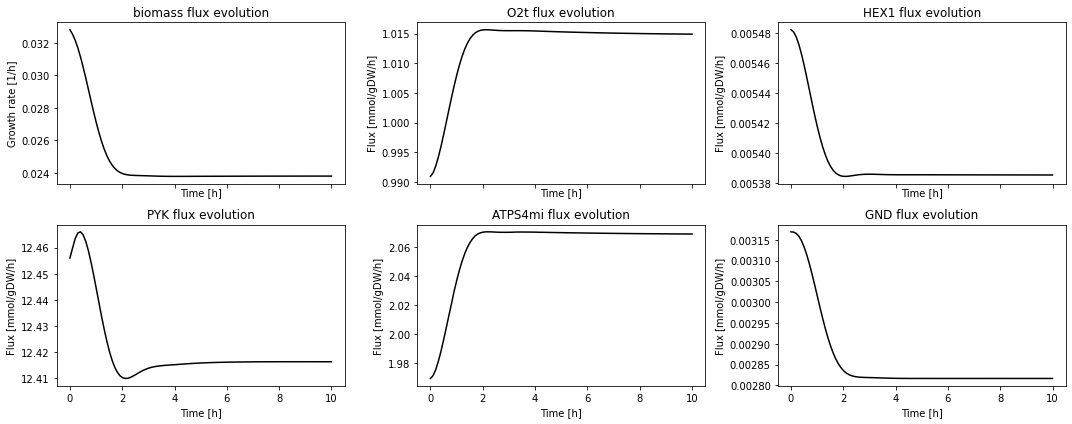

In [107]:
missing_reactions = [reaction for reaction in REACTIONS if reaction not in flux_solution.columns]
if len(missing_reactions) > 0:
    raise KeyError('Reaction(s) not found in flux_solution: {}'.format(missing_reactions))

ncols = 3
nrows = int(np.ceil(len(REACTIONS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, reaction in zip(axes, REACTIONS):
    ax.plot(flux_solution.index, flux_solution[reaction], color='black')
    if reaction == 'biomass':
        ax.set_ylabel('Growth rate [1/h]')
    else:
        ax.set_ylabel('Flux [mmol/gDW/h]')
    ax.set_title('{} flux evolution'.format(reaction))

for ax in axes[len(REACTIONS):]:
    ax.axis('off')

for ax in axes[:len(REACTIONS)]:
    ax.set_xlabel('Time [h]')

plt.tight_layout()
plt.show()

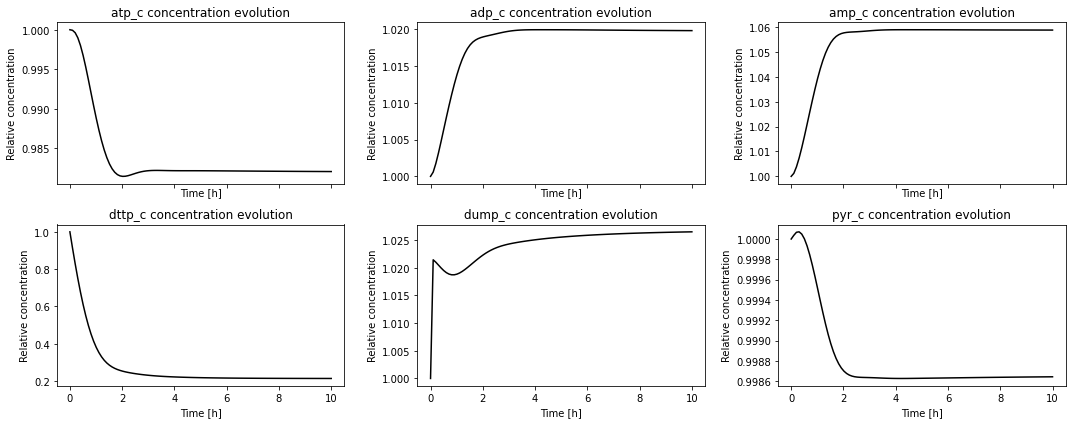

In [108]:
available_metabolites = [met for met in METABOLITES if met in concentration_solution.columns]
if len(available_metabolites) == 0:
    raise KeyError('No selected metabolites were found in concentration_solution.')

ncols = 3
nrows = int(np.ceil(len(available_metabolites) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, met in zip(axes, available_metabolites):
    ax.plot(concentration_solution.index,
            concentration_solution[met] / concentration_solution[met][0],
            color='black')
    ax.set_ylabel('Relative concentration')
    ax.set_title('{} concentration evolution'.format(met))

for ax in axes[len(available_metabolites):]:
    ax.axis('off')

for ax in axes[:len(available_metabolites)]:
    ax.set_xlabel('Time [h]')

plt.tight_layout()
plt.show()